## Notebook overview
- This notebook performs a comprehensive evaluation of multiple machine‑learning classifiers for predicting a binary prostate cancer outcome, where class 0 corresponds to ISUP grades 0–2 and class 1 corresponds to ISUP grades ≥3.
- It includes data preparation, class‑imbalance handling, nested cross‑validation, hyperparameter tuning and uncertainty estimation.

- Three experiments are conducted to adress the imbalance in ISUP grades:

    - Original imbalanced dataset

    - Undersampled dataset

    - Undersampled + SMOTE dataset
- All classification experiments are carried out using scikit‑learn.
- The results of these experiments illustrate how different imbalance‑handling strategies affect model performance, stability and uncertainty. These findings guide the design choices and modeling decisions used in the other notebooks in this project.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

from scipy.stats import entropy
from tqdm import tqdm
from IPython.display import display

from deep_gp.preprocessing_data import load_data, undersample_class0, apply_smote


In [14]:
def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    # Base models
    base_models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=30000,
                tol=1e-4
            ))
        ]),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),

        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                tree_method="hist",
                eval_metric="logloss",
                random_state=42
            ))
        ]),

        "Gaussian Process": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianProcessClassifier(
                kernel=C(1.0, (1e-6, 1e6)) *
                       RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                       WhiteKernel(noise_level=1e-3),
                n_restarts_optimizer=2,
                random_state=42
            ))
        ])
    }

    # Hyperparameter grids
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1.0]
        },
        "KNN": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200, 300, 400, 500],
            "clf__max_depth": [None, 5, 10, 20],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", "log2", None]
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200, 300, 400],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.3],
            "clf__max_depth": [3, 4, 5, 6],
            "clf__subsample": [0.7, 0.8, 0.9, 1.0],
            "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        "Gaussian Process": {
            "clf__kernel": [
                C(c, (1e-6, 1e6)) * RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
                WhiteKernel(noise_level=1e-3)
                for c in [0.5, 1.0, 2.0]
                for l in [0.5, 1.0, 2.0]
            ] + [RBF(1.0)],
            "clf__n_restarts_optimizer": [0, 2]
        }
    }

    # Outer CV
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name, base_model in base_models.items():
        print(f"\n=== Evaluation: {model_name} ===")

        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros(len(y))
        uncertainty_all = np.zeros(len(y))

        best_params_last_fold = None

        for train_idx, test_idx in tqdm(
            skf_outer.split(X, y),
            total=skf_outer.get_n_splits(),
            desc=f"Outer CV ({model_name})"
        ):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            model_clone = clone(base_model)

            if model_name in ["Random Forest", "XGBoost"]:
                tuner = RandomizedSearchCV(
                    model_clone,
                    param_distributions=param_grids[model_name],
                    n_iter=20,
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1,
                    random_state=42
                )
            else:
                tuner = GridSearchCV(
                    model_clone,
                    param_grid=param_grids[model_name],
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1
                )

            tuner.fit(X_train, y_train)
            best_model = tuner.best_estimator_
            best_params_last_fold = tuner.best_params_

            best_model.fit(X_train, y_train)

            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = best_model.predict(X_test)

            probs = np.vstack([y_prob, 1 - y_prob])
            uncertainty = entropy(probs, base=2, axis=0)

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

        print("\n>>> Best hyperparameters (last outer fold):", best_params_last_fold)
        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC:", roc_auc_score(y, y_prob_all))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Uncertainty (Pred=0):", uncertainty_all[y_pred_all == 0].mean())
        print("Uncertainty (Pred=1):", uncertainty_all[y_pred_all == 1].mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

        fpr, tpr, _ = roc_curve(y, y_prob_all)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} — ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        results[model_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "roc_auc": roc_auc_val,
            "accuracy": accuracy_score(y, y_pred_all),
            "mean_uncertainty": uncertainty_all.mean(),
            "uncertainty_0": uncertainty_all[y_pred_all == 0].mean(),
            "uncertainty_1": uncertainty_all[y_pred_all == 1].mean()
        }

    summary_df = pd.DataFrame([
        {
            "Model": name,
            "Accuracy": m["accuracy"],
            "ROC-AUC": m["roc_auc"],
            "Mean Uncertainty": m["mean_uncertainty"],
            "Uncertainty (Pred=0)": m["uncertainty_0"],
            "Uncertainty (Pred=1)": m["uncertainty_1"]
        }
        for name, m in results.items()
    ])

    print("\n=== Summary Table ===")
    display(summary_df)

    plt.figure(figsize=(8, 6))
    for model_name, m in results.items():
        plt.plot(m["fpr"], m["tpr"], lw=2,
                 label=f'{model_name} (AUC = {m["roc_auc"]:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {label}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [ ]:
# LOAD ORIGINAL DATA
data = load_data()

In [16]:
# Experiment 1 — Original Imbalanced Dataset
df_original = data.copy()
df_original["binary_target"] = (df_original["case_ISUP"] >= 3).astype(int)

X_original = df_original.drop(columns=["case_ISUP", "binary_target"])
y_original = df_original["binary_target"]

print("Original class counts:")
print(df_original["case_ISUP"].value_counts())


Original class counts:
case_ISUP
0    589
1    157
2    154
3     69
5     35
4     27
Name: count, dtype: int64


In [17]:
# Experiment 2 — Undersampled Dataset
df_under = undersample_class0(data)
df_under["binary_target"] = (df_under["case_ISUP"] >= 3).astype(int)

X_under = df_under.drop(columns=["case_ISUP", "binary_target"])
y_under = df_under["binary_target"]

print("Class counts after undersampling:")
print(df_under["case_ISUP"].value_counts())


Class counts after undersampling:
case_ISUP
0    262
1    157
2    154
3     69
5     35
4     27
Name: count, dtype: int64


In [18]:
#  Experiment 3 — Undersampled + SMOTE
df_smote = undersample_class0(data)
df_smote = apply_smote(df_smote)
df_smote["binary_target"] = (df_smote["case_ISUP"] >= 3).astype(int)

X_smote = df_smote.drop(columns=["case_ISUP", "binary_target"])
y_smote = df_smote["binary_target"]

print("Class counts after undersampling + SMOTE:")
print(df_smote["case_ISUP"].value_counts())


Class counts after undersampling + SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
5    150
4    150
Name: count, dtype: int64



=== Feature set: Original Imbalanced ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:22<00:00,  4.44s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 1.0}
Accuracy: 0.8739088263821533
ROC-AUC: 0.6147413061916879
Mean uncertainty: 0.5034948200889428
Uncertainty (Pred=0): 0.5011958153915518
Uncertainty (Pred=1): 0.9752505839935743
Confusion matrix:
 [[898   2]
 [128   3]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       900
           1       0.60      0.02      0.04       131

    accuracy                           0.87      1031
   macro avg       0.74      0.51      0.49      1031
weighted avg       0.84      0.87      0.82      1031



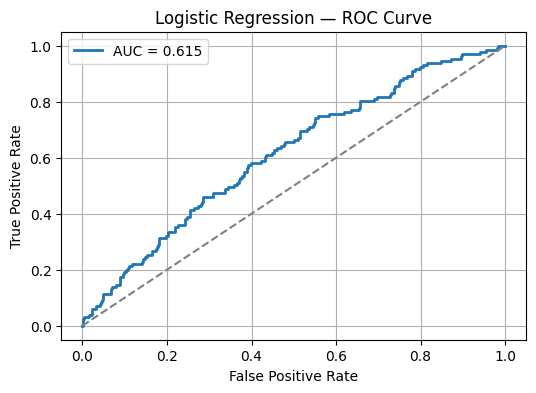


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:01<00:00,  4.87it/s]



>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 7, 'clf__weights': 'uniform'}
Accuracy: 0.8690591658583899
ROC-AUC: 0.6127226463104325
Mean uncertainty: 0.4162396889587764
Uncertainty (Pred=0): 0.41401734748112407
Uncertainty (Pred=1): 0.9868258633460025
Confusion matrix:
 [[896   4]
 [131   0]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       900
           1       0.00      0.00      0.00       131

    accuracy                           0.87      1031
   macro avg       0.44      0.50      0.46      1031
weighted avg       0.76      0.87      0.81      1031



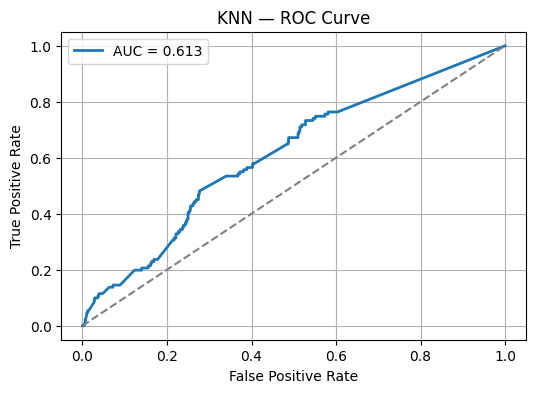


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [03:48<00:00, 45.74s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 10}
Accuracy: 0.8486905916585838
ROC-AUC: 0.6024088210347752
Mean uncertainty: 0.7135798872170925
Uncertainty (Pred=0): 0.7033733180506867
Uncertainty (Pred=1): 0.9877779886064846
Confusion matrix:
 [[869  31]
 [125   6]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       900
           1       0.16      0.05      0.07       131

    accuracy                           0.85      1031
   macro avg       0.52      0.51      0.49      1031
weighted avg       0.78      0.85      0.81      1031



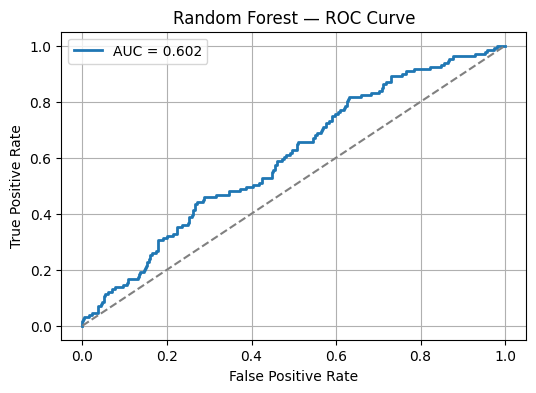


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [01:52<00:00, 22.45s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.8}
Accuracy: 0.8709990300678953
ROC-AUC: 0.6151993214588634
Mean uncertainty: 0.44461551024086204
Uncertainty (Pred=0): 0.44260959890367285
Uncertainty (Pred=1): 0.9596332460641861
Confusion matrix:
 [[897   3]
 [130   1]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       900
           1       0.25      0.01      0.01       131

    accuracy                           0.87      1031
   macro avg       0.56      0.50      0.47      1031
weighted avg       0.79      0.87      0.81      1031



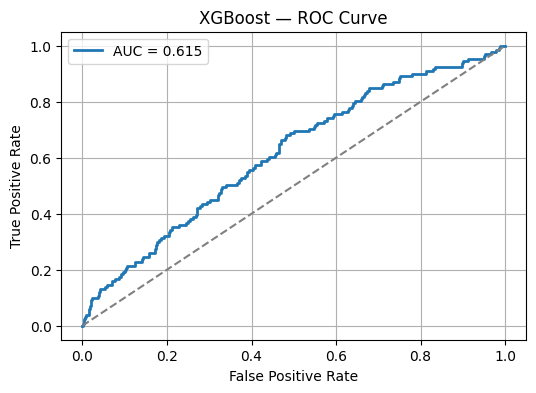


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 1**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 2}
Accuracy: 0.8729388942774006
ROC-AUC: 0.6213401187446989
Mean uncertainty: 0.5479689729782081
Uncertainty (Pred=0): 0.5479689729782081
Uncertainty (Pred=1): nan
Confusion matrix:
 [[900   0]
 [131   0]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       900
           1       0.00      0.00      0.00       131

    accuracy                           0.87      1031
   macro avg       0.44      0.50      0.47      1031
weighted avg       0.76      0.87      0.81      1031




/tmp/ipykernel_20501/940744366.py:148: RuntimeWarning: Mean of empty slice.
  print("Uncertainty (Pred=1):", uncertainty_all[y_pred_all == 1].mean())
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

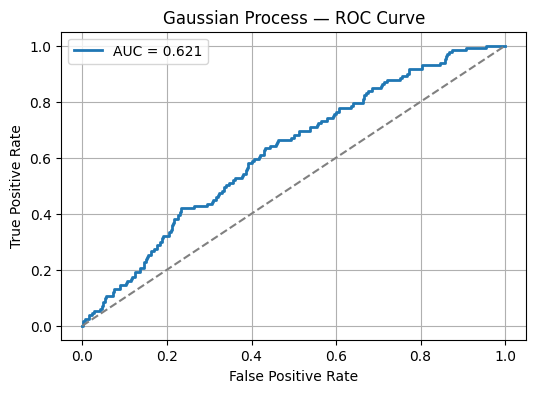


=== Summary Table ===


/tmp/ipykernel_20501/940744366.py:172: RuntimeWarning: Mean of empty slice.
  "uncertainty_1": uncertainty_all[y_pred_all == 1].mean()
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.873909,0.614741,0.503495,0.501196,0.975251
1,KNN,0.869059,0.612723,0.416240,0.414017,0.986826
2,Random Forest,0.848691,0.602409,0.713580,0.703373,0.987778
3,XGBoost,0.870999,0.615199,0.444616,0.442610,0.959633
4,Gaussian Process,0.872939,0.621340,0.547969,0.547969,NaN


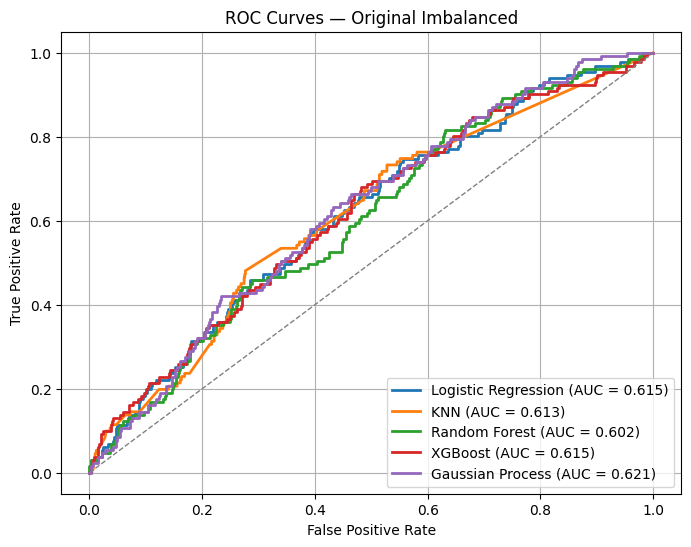


=== Feature set: Undersampled ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 0.01}
Accuracy: 0.8096590909090909
ROC-AUC: 0.6026271265470338
Mean uncertainty: 0.6645393078919386
Uncertainty (Pred=0): 0.6633693259452935
Uncertainty (Pred=1): 0.8281027840329344
Confusion matrix:
 [[569   4]
 [130   1]]
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       573
           1       0.20      0.01      0.01       131

    accuracy                           0.81       704
   macro avg       0.51      0.50      0.45       704
weighted avg       0.70      0.81      0.73       704



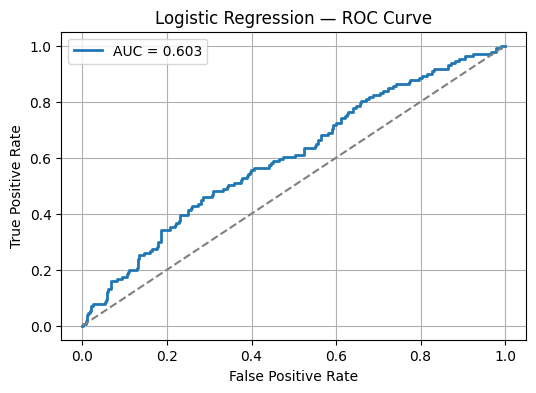


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:00<00:00,  8.54it/s]


>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 7, 'clf__weights': 'distance'}
Accuracy: 0.7982954545454546
ROC-AUC: 0.5586240890984906
Mean uncertainty: 0.5584174197140294
Uncertainty (Pred=0): 0.5491772962014807
Uncertainty (Pred=1): 0.9828470930570999
Confusion matrix:
 [[560  13]
 [129   2]]
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       573
           1       0.13      0.02      0.03       131

    accuracy                           0.80       704
   macro avg       0.47      0.50      0.46       704
weighted avg       0.69      0.80      0.73       704



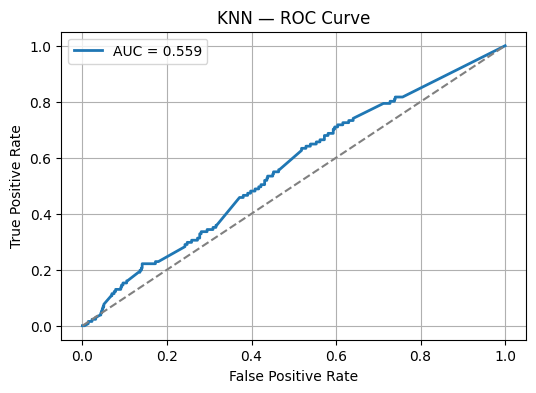


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [02:27<00:00, 29.44s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Accuracy: 0.8039772727272727
ROC-AUC: 0.5570920426841452
Mean uncertainty: 0.7745579418711107
Uncertainty (Pred=0): 0.767945967442935
Uncertainty (Pred=1): 0.9896045387494045
Confusion matrix:
 [[559  14]
 [124   7]]
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       573
           1       0.33      0.05      0.09       131

    accuracy                           0.80       704
   macro avg       0.58      0.51      0.49       704
weighted avg       0.73      0.80      0.74       704



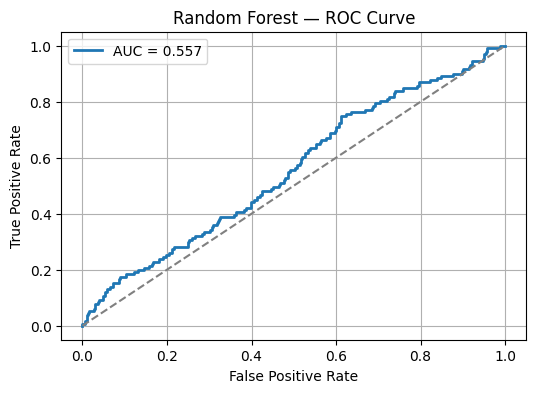


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [01:44<00:00, 20.99s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__max_depth': 3, 'clf__learning_rate': 0.3, 'clf__colsample_bytree': 0.9}
Accuracy: 0.7883522727272727
ROC-AUC: 0.549072112758616
Mean uncertainty: 0.322758131859783
Uncertainty (Pred=0): 0.29905671658387073
Uncertainty (Pred=1): 0.7898154328851139
Confusion matrix:
 [[547  26]
 [123   8]]
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       573
           1       0.24      0.06      0.10       131

    accuracy                           0.79       704
   macro avg       0.53      0.51      0.49       704
weighted avg       0.71      0.79      0.73       704



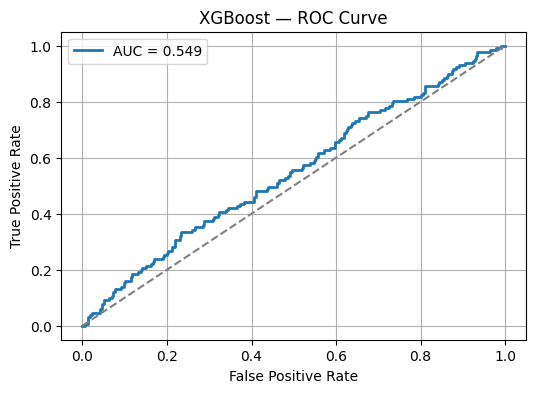


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 1.41**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.7926136363636364
ROC-AUC: 0.5586374112412241
Mean uncertainty: 0.751137682811461
Uncertainty (Pred=0): 0.7435291022589827
Uncertainty (Pred=1): 0.9985977074468211
Confusion matrix:
 [[555  18]
 [128   3]]
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       573
           1       0.14      0.02      0.04       131

    accuracy                           0.79       704
   macro avg       0.48      0.50      0.46       704
weighted avg       0.69      0.79      0.73       704



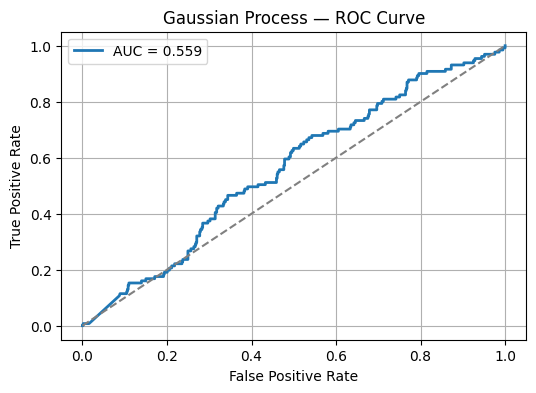


=== Summary Table ===


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.809659,0.602627,0.664539,0.663369,0.828103
1,KNN,0.798295,0.558624,0.558417,0.549177,0.982847
2,Random Forest,0.803977,0.557092,0.774558,0.767946,0.989605
3,XGBoost,0.788352,0.549072,0.322758,0.299057,0.789815
4,Gaussian Process,0.792614,0.558637,0.751138,0.743529,0.998598


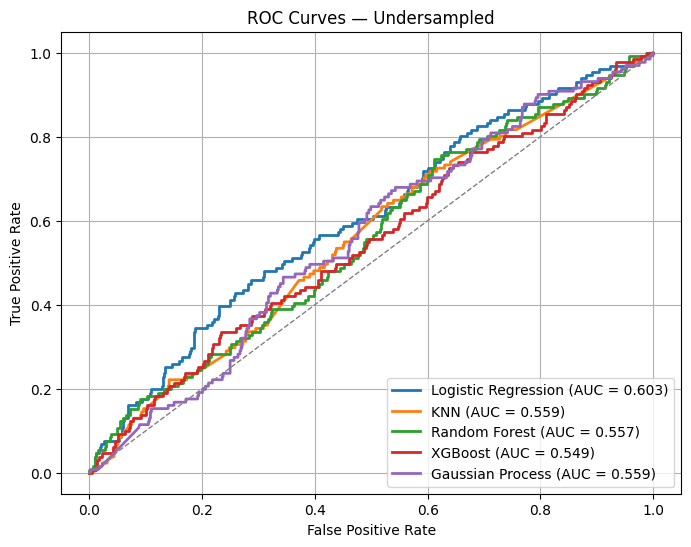


=== Feature set: Undersampled + SMOTE ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:15<00:00,  3.12s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 1.0}
Accuracy: 0.6999022482893451
ROC-AUC: 0.7462245491564864
Mean uncertainty: 0.8280837566438738
Uncertainty (Pred=0): 0.7964338391590299
Uncertainty (Pred=1): 0.8729772566223757
Confusion matrix:
 [[433 140]
 [167 283]]
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       573
           1       0.67      0.63      0.65       450

    accuracy                           0.70      1023
   macro avg       0.70      0.69      0.69      1023
weighted avg       0.70      0.70      0.70      1023



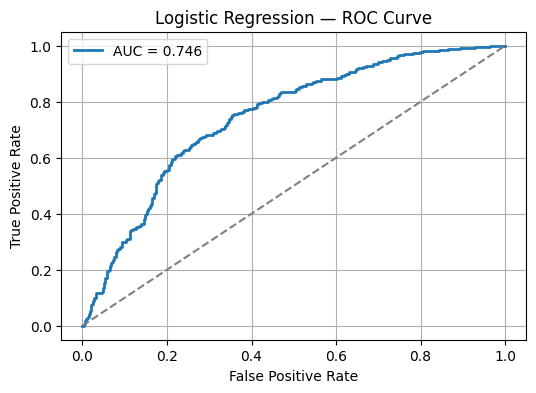


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:00<00:00,  7.50it/s]



>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 5, 'clf__weights': 'distance'}
Accuracy: 0.7565982404692082
ROC-AUC: 0.8584293193717277
Mean uncertainty: 0.5077067549416858
Uncertainty (Pred=0): 0.5331408865059032
Uncertainty (Pred=1): 0.48984784725433195
Confusion matrix:
 [[373 200]
 [ 49 401]]
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       573
           1       0.67      0.89      0.76       450

    accuracy                           0.76      1023
   macro avg       0.78      0.77      0.76      1023
weighted avg       0.79      0.76      0.76      1023



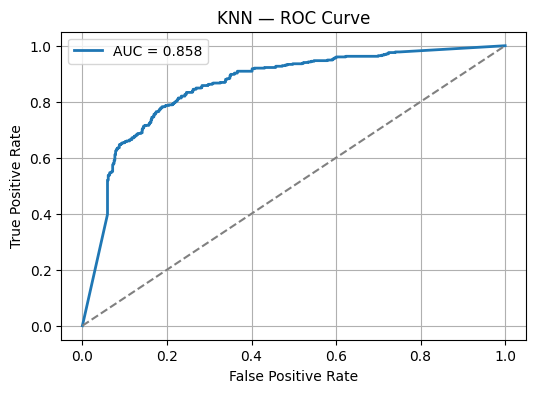


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [04:37<00:00, 55.42s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Accuracy: 0.8455522971652004
ROC-AUC: 0.9032770990886174
Mean uncertainty: 0.8033331761354149
Uncertainty (Pred=0): 0.8147921704700853
Uncertainty (Pred=1): 0.7868813342692093
Confusion matrix:
 [[509  64]
 [ 94 356]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       573
           1       0.85      0.79      0.82       450

    accuracy                           0.85      1023
   macro avg       0.85      0.84      0.84      1023
weighted avg       0.85      0.85      0.84      1023



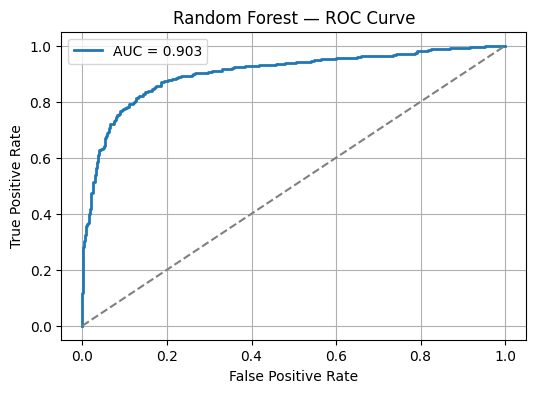


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [02:09<00:00, 25.83s/it]


>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.7, 'clf__n_estimators': 400, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.8}
Accuracy: 0.8582600195503421
ROC-AUC: 0.9125887143688192
Mean uncertainty: 0.4734795106309061
Uncertainty (Pred=0): 0.4546573598997038
Uncertainty (Pred=1): 0.4969761735217257
Confusion matrix:
 [[498  75]
 [ 70 380]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       573
           1       0.84      0.84      0.84       450

    accuracy                           0.86      1023
   macro avg       0.86      0.86      0.86      1023
weighted avg       0.86      0.86      0.86      1023



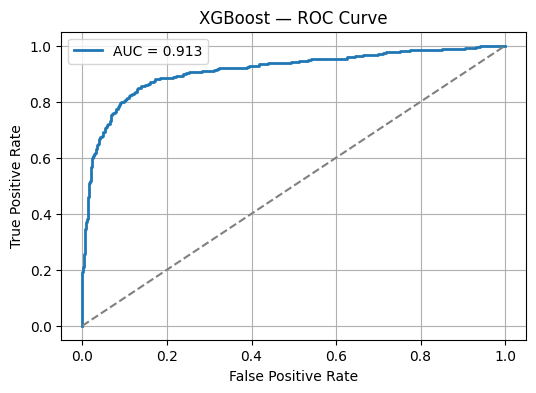


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 0.707**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.841642228739003
ROC-AUC: 0.9171999224355245
Mean uncertainty: 0.7857703069332227
Uncertainty (Pred=0): 0.8128382384129884
Uncertainty (Pred=1): 0.7583293921456649
Confusion matrix:
 [[463 110]
 [ 52 398]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       573
           1       0.78      0.88      0.83       450

    accuracy                           0.84      1023
   macro avg       0.84      0.85      0.84      1023
weighted avg       0.85      0.84      0.84      1023



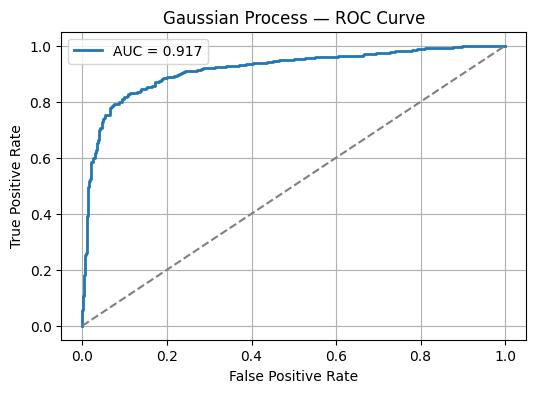


=== Summary Table ===


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.699902,0.746225,0.828084,0.796434,0.872977
1,KNN,0.756598,0.858429,0.507707,0.533141,0.489848
2,Random Forest,0.845552,0.903277,0.803333,0.814792,0.786881
3,XGBoost,0.858260,0.912589,0.473480,0.454657,0.496976
4,Gaussian Process,0.841642,0.917200,0.785770,0.812838,0.758329


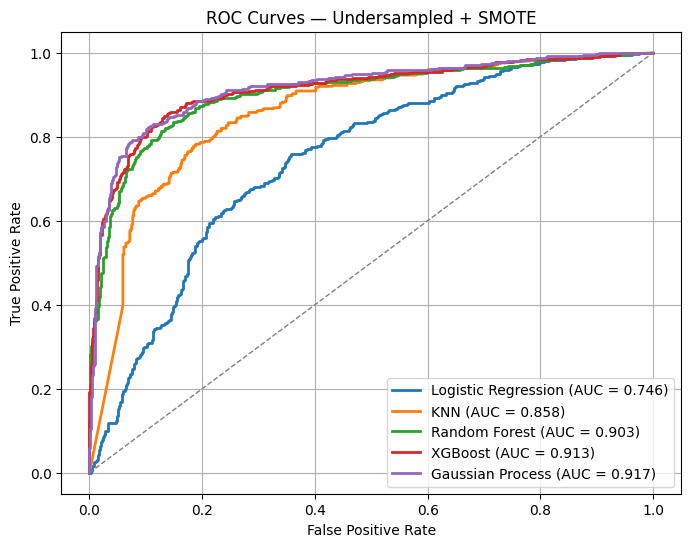

In [19]:

evaluate_models_cv_with_tuning(X_original, y_original, "Original Imbalanced")
evaluate_models_cv_with_tuning(X_under, y_under, "Undersampled")
evaluate_models_cv_with_tuning(X_smote, y_smote, "Undersampled + SMOTE")
